##Código Maestro de Verificación (Referencia Docente)

In [ ]:
import sympy as sp
import numpy as np

def verify_gimbal_lock_symbolic () :
  print ("=== VERIFICACION SIMBOLICA DE GIMBAL LOCK (ZYZ) ===")
  phi , theta , psi = sp . symbols ('phi theta psi ', real = True )

  # Matrices de rotacion canonicas simbolicas
  Rz1 = sp . Matrix ([[ sp . cos ( phi ) , - sp . sin ( phi ) , 0] ,
  [ sp . sin ( phi ) , sp . cos ( phi ) , 0] ,
  [0 , 0 , 1]])
  Ry = sp . Matrix ([[ sp . cos ( theta ) , 0, sp . sin ( theta ) ] ,
  [0 , 1 , 0] ,
  [ - sp . sin ( theta ) , 0 , sp . cos ( theta ) ]])
  Rz2 = sp . Matrix ([[ sp . cos ( psi ) , - sp . sin ( psi ) , 0] ,
  [ sp . sin ( psi ) , sp . cos ( psi ) , 0] ,
  [0 , 0 , 1]])

  # Matriz Euler ZYZ y Evaluacion en theta = 0
  R_zyz = Rz1 * Ry * Rz2
  R_singular = sp . simplify ( R_zyz . subs ( theta , 0) )
  print ("\nMatriz R_ZYZ en theta = 0:")
  sp . pprint ( R_singular )

  # Demostrar dependencia de ( phi + psi )
  alpha = sp . symbols ('alpha ')
  R_expected = sp . Matrix ([[ sp . cos ( alpha ) , - sp . sin ( alpha ) , 0] ,
  [ sp . sin ( alpha ) , sp . cos ( alpha ) , 0] ,
  [0 , 0 , 1]])
  print ("\nEs equivalente a Rz( phi + psi )?:",
  R_singular == R_expected . subs ( alpha , phi + psi ) )

if __name__ == "__main__":
  verify_gimbal_lock_symbolic ()

=== VERIFICACION SIMBOLICA DE GIMBAL LOCK (ZYZ) ===

Matriz R_ZYZ en theta = 0:
⎡cos(φ + ψ)  -sin(φ + ψ)  0⎤
⎢                          ⎥
⎢sin(φ + ψ)  cos(φ + ψ)   0⎥
⎢                          ⎥
⎣    0            0       1⎦

Es equivalente a Rz( phi + psi )?: True


##Ejercicio 2

In [ ]:
import sympy as sp

def analizar_gimbal_lock_zyz():
    print("EJERCICIO 2: ANÁLISIS SENSORIAL Y SIMBÓLICO DE GIMBAL LOCK (ZYZ)")

    # 1. Variables simbólicas
    phi, theta, psi = sp.symbols('phi theta psi', real=True)

    # 2. Matrices de rotación canónicas ZYZ
    Rz1 = sp.Matrix([
        [sp.cos(phi), -sp.sin(phi), 0],
        [sp.sin(phi),  sp.cos(phi), 0],
        [0, 0, 1]
    ])

    Ry = sp.Matrix([
        [ sp.cos(theta), 0, sp.sin(theta)],
        [0, 1, 0],
        [-sp.sin(theta), 0, sp.cos(theta)]
    ])

    Rz2 = sp.Matrix([
        [sp.cos(psi), -sp.sin(psi), 0],
        [sp.sin(psi),  sp.cos(psi), 0],
        [0, 0, 1]
    ])

    # Matriz Euler ZYZ completa
    R_zyz = Rz1 * Ry * Rz2

    # 3. Sustitución de theta = 0 (Postura erguida / Gimbal Lock)
    R_singular = sp.simplify(R_zyz.subs(theta, 0))

    print("\nA) Matriz R_ZYZ evaluada en theta = 0:")
    sp.pprint(R_singular)

    # 4. Cálculo de derivadas parciales
    dR_dphi = sp.diff(R_singular, phi)
    dR_dpsi = sp.diff(R_singular, psi)

    print("\nB) Derivada Parcial respectiva a phi (dR/dphi | theta=0):")
    sp.pprint(dR_dphi)

    print("\nC) Derivada Parcial respectiva a psi (dR/dpsi | theta=0):")
    sp.pprint(dR_dpsi)

    # 5. Demostración de igualdad de derivadas
    son_linealmente_dependientes = (dR_dphi == dR_dpsi)
    print(f"\n¿Las derivadas dR/dphi y dR/dpsi son idénticas?: {son_linealmente_dependientes}")

    assert son_linealmente_dependientes, "Error: Las derivadas no coinciden"
    print("\n dR/dphi = dR/dpsi cuando theta = 0.")
    print("Esto prueba que ambas variables producen exactamente el mismo cambio helicoidal,")
    print("causando la pérdida de 1 Grado de Libertad Representacional (Gimbal Lock).")

if __name__ == "__main__":
    analizar_gimbal_lock_zyz()

EJERCICIO 2: ANÁLISIS SENSORIAL Y SIMBÓLICO DE GIMBAL LOCK (ZYZ)

A) Matriz R_ZYZ evaluada en theta = 0:
⎡cos(φ + ψ)  -sin(φ + ψ)  0⎤
⎢                          ⎥
⎢sin(φ + ψ)  cos(φ + ψ)   0⎥
⎢                          ⎥
⎣    0            0       1⎦

B) Derivada Parcial respectiva a phi (dR/dphi | theta=0):
⎡-sin(φ + ψ)  -cos(φ + ψ)  0⎤
⎢                           ⎥
⎢cos(φ + ψ)   -sin(φ + ψ)  0⎥
⎢                           ⎥
⎣     0            0       0⎦

C) Derivada Parcial respectiva a psi (dR/dpsi | theta=0):
⎡-sin(φ + ψ)  -cos(φ + ψ)  0⎤
⎢                           ⎥
⎢cos(φ + ψ)   -sin(φ + ψ)  0⎥
⎢                           ⎥
⎣     0            0       0⎦

¿Las derivadas dR/dphi y dR/dpsi son idénticas?: True

 dR/dphi = dR/dpsi cuando theta = 0.
Esto prueba que ambas variables producen exactamente el mismo cambio helicoidal,
causando la pérdida de 1 Grado de Libertad Representacional (Gimbal Lock).


##Ejercicio3


CASO 1: theta = 0.0001°
Matriz R_ZYZ:
[[ 2.58819e-01 -9.65926e-01  1.00000e-06]
 [ 9.65926e-01  2.58819e-01  1.00000e-06]
 [-2.00000e-06  1.00000e-06  1.00000e+00]]
Ángulos Reales     : phi=45.0000°, theta=0.000100°, psi=30.0000°
Ángulos Extraídos  : phi=45.0000°, theta=0.000100°, psi=30.0000°

CASO 2: theta = 1e-11° (Gimbal Lock Numérico)
Matriz R_ZYZ:
[[ 0.258819 -0.965926  0.      ]
 [ 0.965926  0.258819  0.      ]
 [-0.        0.        1.      ]]
Ángulos Reales     : phi=45.0000°, theta=1.00e-11°, psi=30.0000°
Ángulos Extraídos  : phi=0.0000°, theta=1.00e-11°, psi=75.0000°
Suma de Ángulos    : phi_calc + psi_calc = 75.0000°



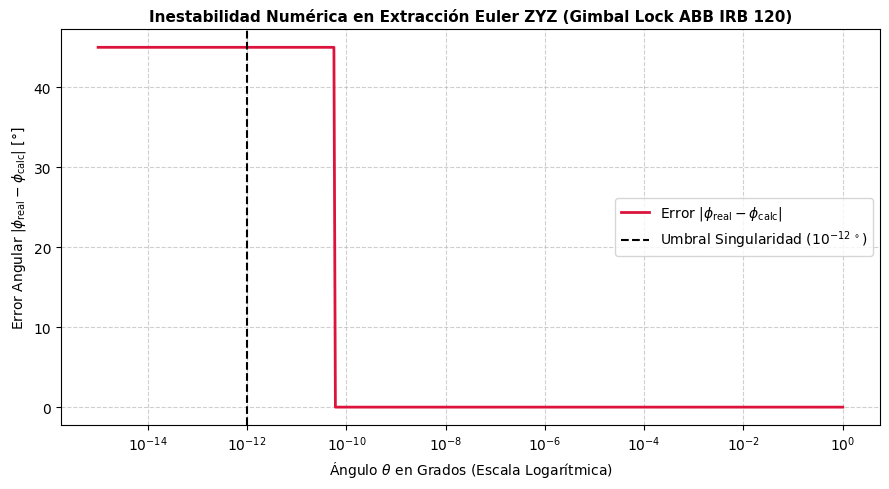

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# 1. FUNCIONES Y FÓRMULAS DE EXTRACCIÓN ZYZ

def get_R_zyz(phi_deg, theta_deg, psi_deg):
    """Calcula R_ZYZ = Rz(phi) * Ry(theta) * Rz(psi)"""
    phi, theta, psi = np.radians([phi_deg, theta_deg, psi_deg])

    Rz1 = np.array([
        [np.cos(phi), -np.sin(phi), 0],
        [np.sin(phi),  np.cos(phi), 0],
        [0, 0, 1]
    ])
    Ry = np.array([
        [ np.cos(theta), 0, np.sin(theta)],
        [0, 1, 0],
        [-np.sin(theta), 0, np.cos(theta)]
    ])
    Rz2 = np.array([
        [np.cos(psi), -np.sin(psi), 0],
        [np.sin(psi),  np.cos(psi), 0],
        [0, 0, 1]
    ])
    return Rz1 @ Ry @ Rz2

def extract_zyz(R, tol=1e-12):
    """
    Extrae los ángulos (phi, theta, psi) de una matriz R_ZYZ dada.
    Maneja la singularidad cuando sin(theta) -> 0.
    """
    sin_theta = np.sqrt(R[0, 2]**2 + R[1, 2]**2)
    cos_theta = R[2, 2]

    theta = np.arctan2(sin_theta, cos_theta)

    if sin_theta > tol:
        phi = np.arctan2(R[1, 2], R[0, 2])
        psi = np.arctan2(R[2, 1], -R[2, 0])
    else:
        # Gimbal Lock: theta = 0 -> R = Rz(phi + psi)
        phi = 0.0
        psi = np.arctan2(R[1, 0], R[0, 0])

    return np.degrees([phi, theta, psi])



# 2. EVALUACIÓN CASO 1 Y CASO 2 (ABB IRB 120)

phi_real, psi_real = 45.0, 30.0

# CASO 1: theta = 0.0001°
theta_caso1 = 0.0001
R_caso1 = get_R_zyz(phi_real, theta_caso1, psi_real)
phi_c1, theta_c1, psi_c1 = extract_zyz(R_caso1)

print("CASO 1: theta = 0.0001°")
print("Matriz R_ZYZ:")
print(np.round(R_caso1, 6))
print(f"Ángulos Reales     : phi={phi_real:.4f}°, theta={theta_caso1:.6f}°, psi={psi_real:.4f}°")
print(f"Ángulos Extraídos  : phi={phi_c1:.4f}°, theta={theta_c1:.6f}°, psi={psi_c1:.4f}°\n")

# CASO 2: theta = 1e-11°
theta_caso2 = 1e-11
R_caso2 = get_R_zyz(phi_real, theta_caso2, psi_real)
phi_c2, theta_c2, psi_c2 = extract_zyz(R_caso2)

print("CASO 2: theta = 1e-11° (Gimbal Lock Numérico)")
print("Matriz R_ZYZ:")
print(np.round(R_caso2, 6))
print(f"Ángulos Reales     : phi={phi_real:.4f}°, theta={theta_caso2:.2e}°, psi={psi_real:.4f}°")
print(f"Ángulos Extraídos  : phi={phi_c2:.4f}°, theta={theta_c2:.2e}°, psi={psi_c2:.4f}°")
print(f"Suma de Ángulos    : phi_calc + psi_calc = {phi_c2 + psi_c2:.4f}°\n")


# 3. GRÁFICA DE ERROR DE EXTRACCIÓN (CORREGIDO)

thetas = np.logspace(-15, 0, 500)
errores_phi = []

for th in thetas:
    R_i = get_R_zyz(phi_real, th, psi_real)
    phi_calc, _, _ = extract_zyz(R_i)
    err = np.abs(phi_real - phi_calc)
    errores_phi.append(err)

plt.figure(figsize=(9, 5))

# Uso de cadenas r"..." y corchetes agrupados para la sintaxis LaTeX de Matplotlib
plt.semilogx(
    thetas,
    errores_phi,
    color='crimson',
    linewidth=2,
    label=r'Error $|\phi_{\mathrm{real}} - \phi_{\mathrm{calc}}|$'
)

plt.axvline(
    x=1e-12,
    color='black',
    linestyle='--',
    label=r'Umbral Singularidad ($10^{-12\,\circ}$)'
)

plt.title('Inestabilidad Numérica en Extracción Euler ZYZ (Gimbal Lock ABB IRB 120)', fontsize=11, fontweight='bold')
plt.xlabel(r'Ángulo $\theta$ en Grados (Escala Logarítmica)', fontsize=10)
plt.ylabel(r'Error Angular $|\phi_{\mathrm{real}} - \phi_{\mathrm{calc}}|$ [°]', fontsize=10)
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend(loc='center right', fontsize=10)
plt.tight_layout()
plt.show()